#Import libraries


In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


#load dataset

In [29]:
df = pd.read_csv("/content/loan approval dataset.zip")

print(df.sample(5))


      loan_id   no_of_dependents      education  self_employed   income_annum  \
2228     2229                  3       Graduate             No        3300000   
1365     1366                  4   Not Graduate             No        7600000   
2817     2818                  4       Graduate             No        8200000   
1108     1109                  4       Graduate             No        8100000   
3516     3517                  1       Graduate            Yes        6900000   

       loan_amount   loan_term   cibil_score   residential_assets_value  \
2228      11100000           2           660                    6500000   
1365      29900000          18           445                    4800000   
2817      25200000          18           691                    5800000   
1108      19000000           6           375                    4100000   
3516      22300000          16           673                   17400000   

       commercial_assets_value   luxury_assets_value   bank_as

In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [67]:
# Remove Loan_ID

# First, clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

df.drop("loan_id", axis=1, inplace=True)

# Features
X = df.drop("loan_status", axis=1)

# Target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["loan_status"])

KeyError: "['loan_id'] not found in axis"

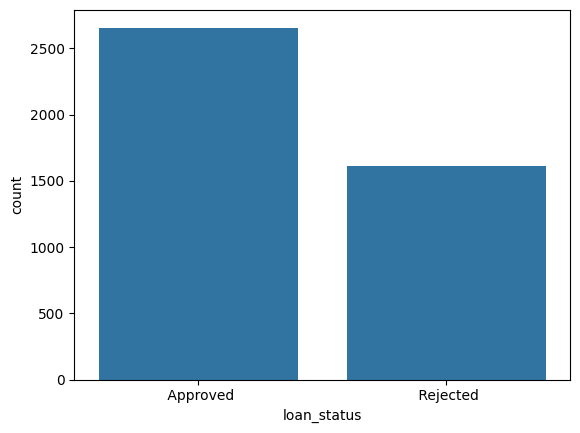

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=df)
plt.show()

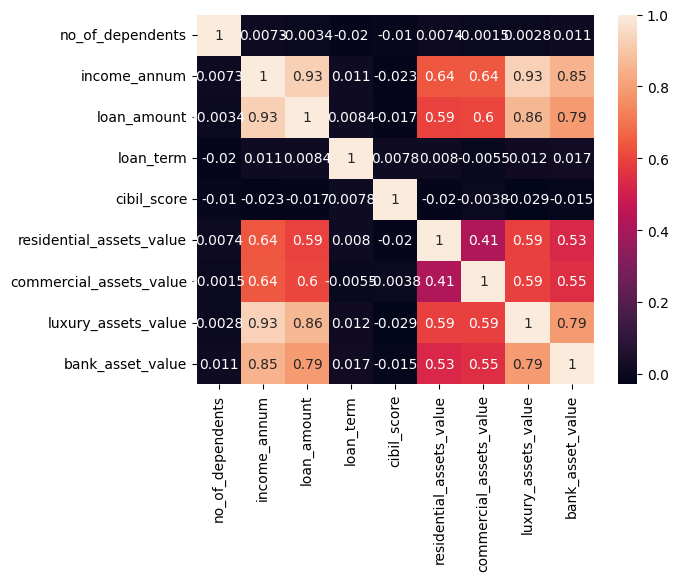

In [52]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.show()

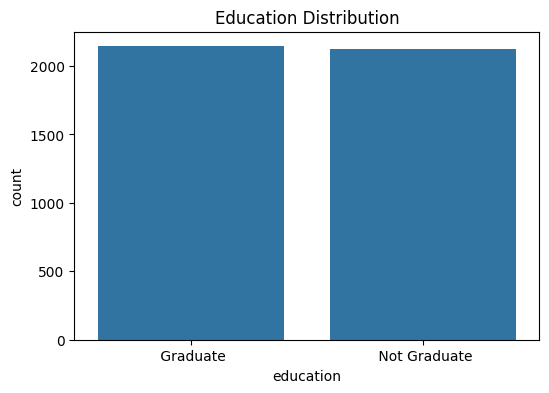

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="education",
    data=df
)

plt.title("Education Distribution")
plt.show()

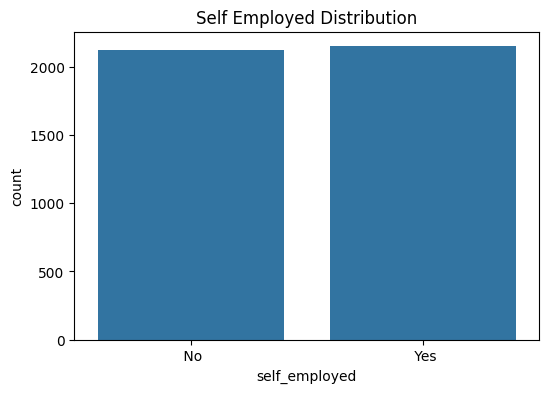

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="self_employed",
    data=df
)

plt.title("Self Employed Distribution")
plt.show()

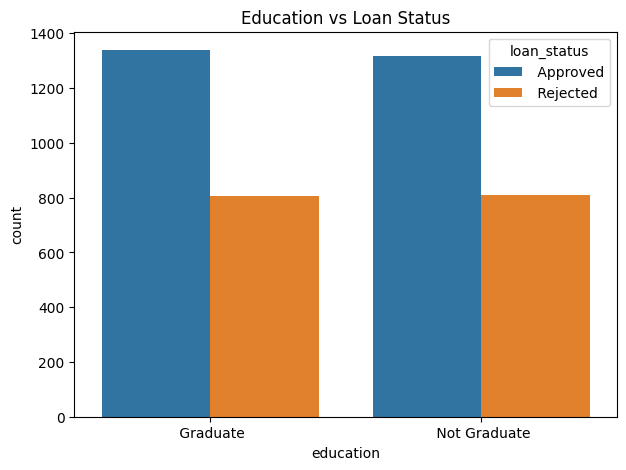

In [55]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="education",
    hue="loan_status",
    data=df
)

plt.title("Education vs Loan Status")
plt.show()

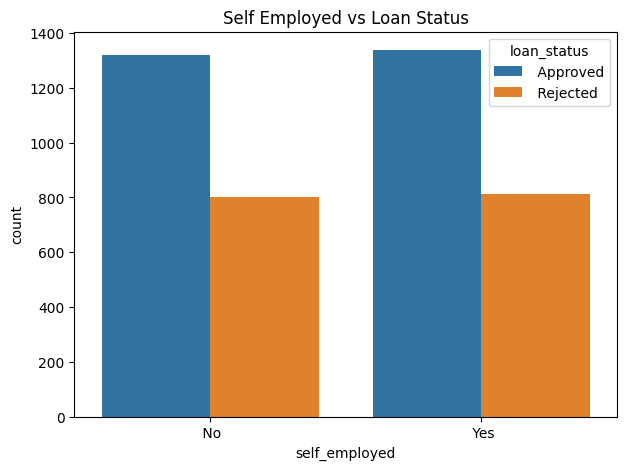

In [56]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="self_employed",
    hue="loan_status",
    data=df
)

plt.title("Self Employed vs Loan Status")
plt.show()

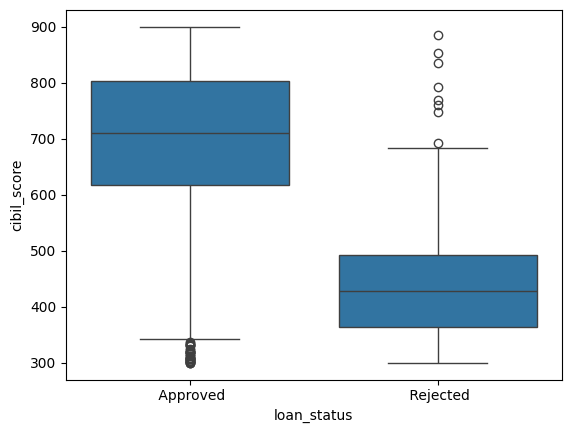

In [63]:
sns.boxplot(
    x='loan_status',
    y='cibil_score',
    data=df
)

plt.show()

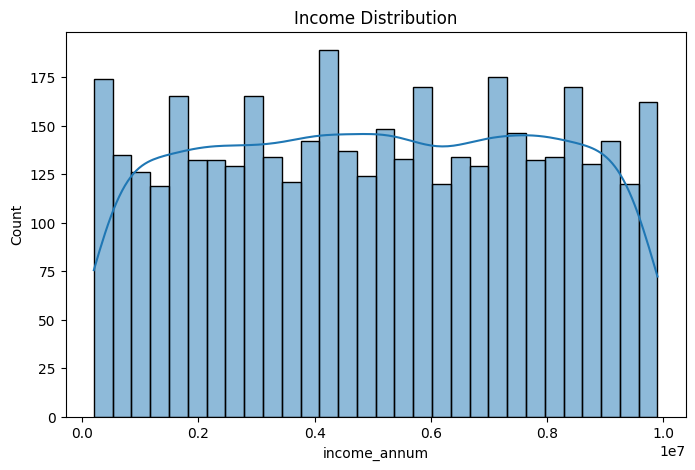

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["income_annum"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.show()

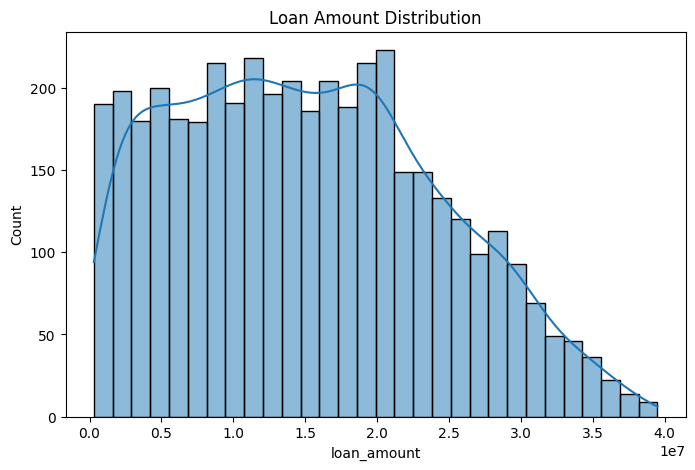

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["loan_amount"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.show()

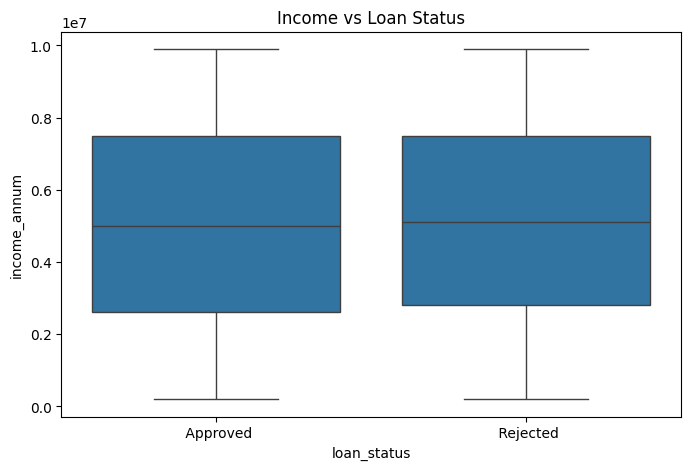

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="income_annum",
    data=df
)

plt.title("Income vs Loan Status")
plt.show()

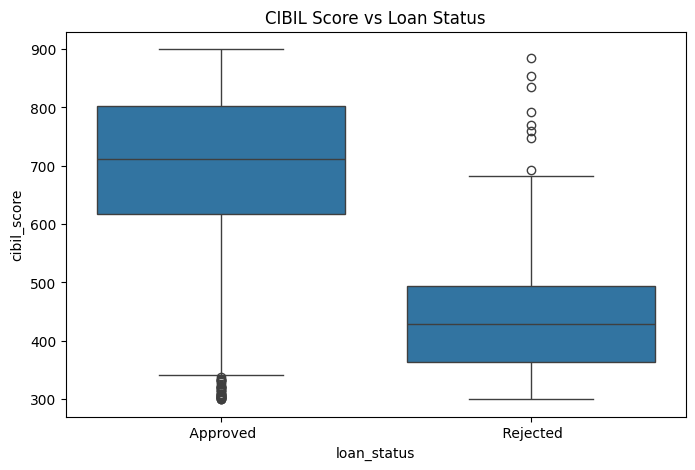

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="cibil_score",
    data=df
)

plt.title("CIBIL Score vs Loan Status")
plt.show()

# "The boxplot shows that approved loans generally have higher
#  CIBIL scores. However, a few rejected applications exhibit high CIBIL
#   scores, indicating that loan approval depends not only on credit score
#   but also on factors such as income, loan amount, and asset values."

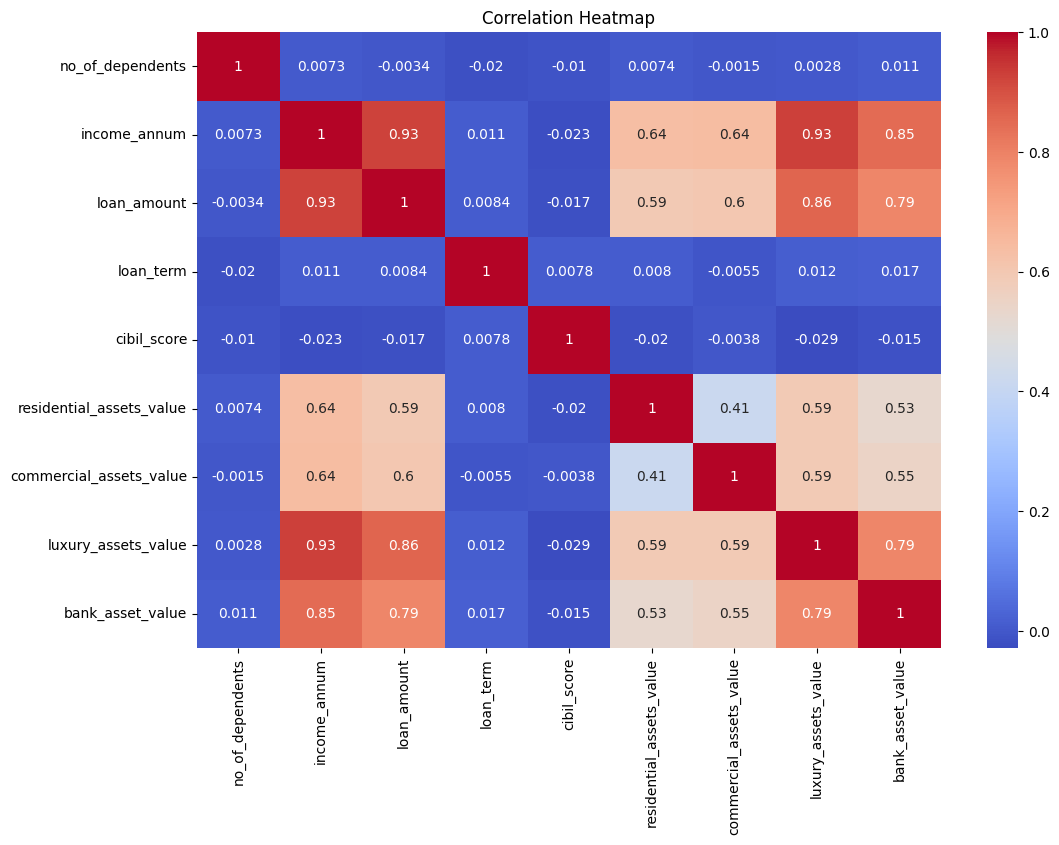

In [73]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [62]:
X["total_assets"] = (
    X["residential_assets_value"]
    + X["commercial_assets_value"]
    + X["luxury_assets_value"]
    + X["bank_asset_value"]
)

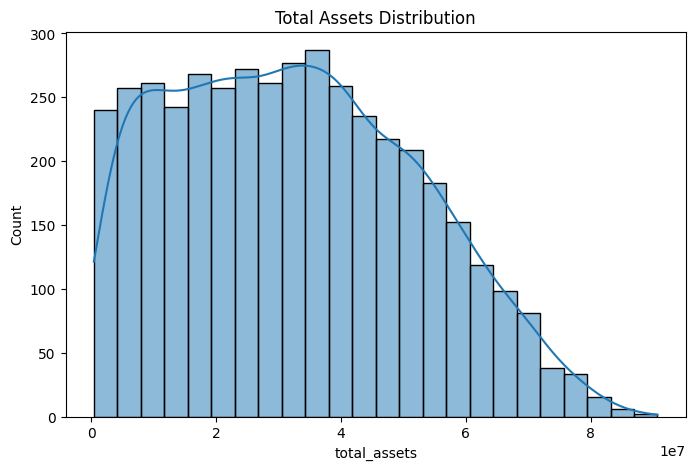

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    X["total_assets"],
    kde=True
)

plt.title("Total Assets Distribution")
plt.show()

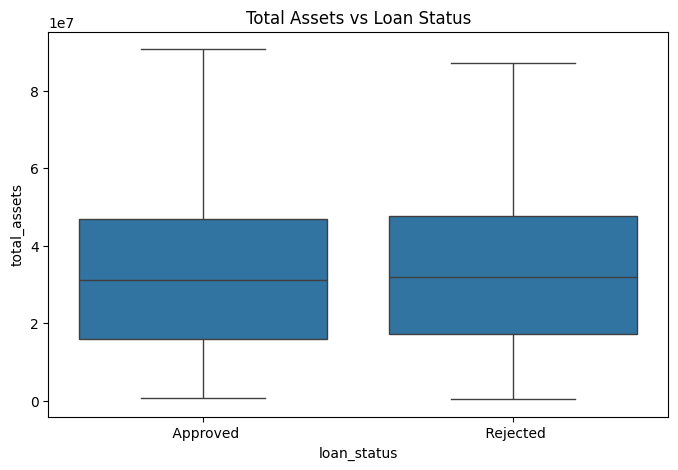

In [76]:
plt.figure(figsize=(8,5))

# Ensure 'total_assets' is in df for plotting
# Make a copy to avoid SettingWithCopyWarning if df was a slice
df_for_plot = df.copy()
df_for_plot['total_assets'] = X['total_assets']

sns.boxplot(
    x="loan_status",
    y="total_assets",
    data=df_for_plot
)

plt.title("Total Assets vs Loan Status")
plt.show()

In [57]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [33]:
X["loan_income_ratio"] = (
    X["loan_amount"] / X["income_annum"]
)

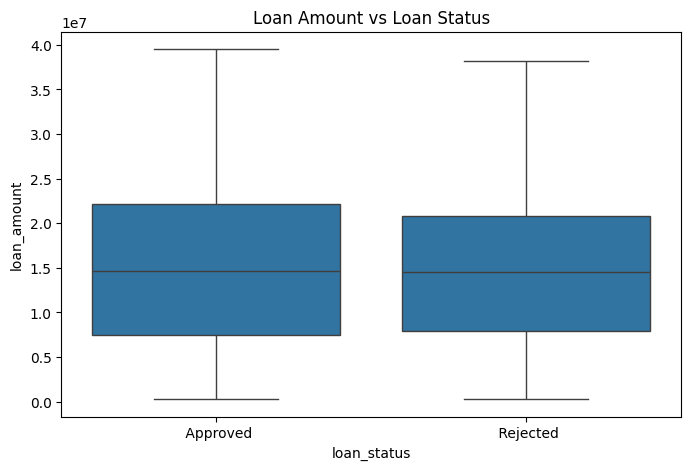

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="loan_amount",
    data=df
)

plt.title("Loan Amount vs Loan Status")
plt.show()

In [34]:
X["asset_loan_ratio"] = (
    X["total_assets"] / X["loan_amount"]
)

In [35]:
num_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
    "total_assets",
    "loan_income_ratio",
    "asset_loan_ratio"
]

cat_cols = [
    "education",
    "self_employed"
]

In [36]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [37]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [38]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

preds = rf_pipeline.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, preds)
)

Accuracy: 1.0


In [42]:
import sys
!{sys.executable} -m pip install optuna
import optuna

from sklearn.model_selection import cross_val_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


In [43]:
def objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500
    )

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        10
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        5
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score

In [44]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-06-06 09:38:00,184] A new study created in memory with name: no-name-993f606f-75e3-421a-85c2-0b3aa65e881a
[I 2026-06-06 09:38:05,500] Trial 0 finished with value: 0.9967789165446559 and parameters: {'n_estimators': 153, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9967789165446559.
[I 2026-06-06 09:38:08,356] Trial 1 finished with value: 0.9964860907759883 and parameters: {'n_estimators': 103, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9967789165446559.
[I 2026-06-06 09:38:17,596] Trial 2 finished with value: 0.9970717423133237 and parameters: {'n_estimators': 461, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.9970717423133237.
[I 2026-06-06 09:38:20,446] Trial 3 finished with value: 0.9964860907759883 and parameters: {'n_estimators': 137, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 2 with value

In [45]:
print("Best Accuracy:")
print(study.best_value)

print("\nBest Parameters:")
print(study.best_params)

Best Accuracy:
0.9982430453879942

Best Parameters:
{'n_estimators': 313, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 1}


In [48]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

final_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value',
                                                   'total_assets',
                                                   'loan_income_ratio',
                                                   'asset_loan_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_split=9,
                                        n_estimators=313, n_jobs=-1,
                                        random_state=42))])

In [49]:
from sklearn.metrics import accuracy_score

preds = final_pipeline.predict(X_test)

print(
    "Test Accuracy:",
    accuracy_score(y_test, preds)
)

Test Accuracy: 1.0


In [66]:
import pandas as pd

# Transform X_train using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

rf = RandomForestClassifier(random_state=42)

# Fit the RandomForestClassifier with the processed data
rf.fit(X_train_processed, y_train)

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

                          Feature  Importance
4                num__cibil_score    0.799341
3                  num__loan_term    0.074614
10         num__loan_income_ratio    0.037300
11          num__asset_loan_ratio    0.021879
2                num__loan_amount    0.009790
6    num__commercial_assets_value    0.009069
5   num__residential_assets_value    0.008805
9               num__total_assets    0.008483
7        num__luxury_assets_value    0.007884
8           num__bank_asset_value    0.007739
1               num__income_annum    0.007459
0           num__no_of_dependents    0.003822
13   cat__education_ Not Graduate    0.000985
15        cat__self_employed_ Yes    0.000959
12       cat__education_ Graduate    0.000938
14         cat__self_employed_ No    0.000934


In [ ]:
import joblib

joblib.dump(
    final_pipeline,
    "loan_approval_model.pkl"
)